In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize images
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']


In [ ]:
def build_ann():
    model = Sequential([
        Flatten(input_shape=(32,32,3)),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same',
               input_shape=(32,32,3)),
        MaxPooling2D((2,2)),

        Conv2D(64, (5,5), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Conv2D(128, (7,7), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
ann = build_ann()
start_time = time.time()

history_ann = ann.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

ann_time = time.time() - start_time

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.1935 - loss: 2.1882 - val_accuracy: 0.3238 - val_loss: 1.8838
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.3005 - loss: 1.9055 - val_accuracy: 0.3392 - val_loss: 1.8293
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 106ms/step - accuracy: 0.3240 - loss: 1.8480 - val_accuracy: 0.3648 - val_loss: 1.7676
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.3434 - loss: 1.8099 - val_accuracy: 0.3880 - val_loss: 1.7292
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.3560 - loss: 1.7695 - val_accuracy: 0.4049 - val_loss: 1.6958
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.3610 - loss: 1.7525 - val_accuracy: 0.3946 - val_loss: 1.7010
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.3804 - loss: 1.7221 - val_accuracy: 0.4101 - val_loss: 1.6872
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.3753 - loss: 1.7190 -

In [ ]:
cnn = build_cnn()
start_time = time.time()

history_cnn = cnn.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

cnn_time = time.time() - start_time

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 286s 907ms/step - accuracy: 0.2785 - loss: 1.9374 - val_accuracy: 0.4975 - val_loss: 1.3671
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 280s 894ms/step - accuracy: 0.5223 - loss: 1.3145 - val_accuracy: 0.5918 - val_loss: 1.1316
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 285s 912ms/step - accuracy: 0.6172 - loss: 1.0824 - val_accuracy: 0.6486 - val_loss: 0.9923
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 284s 907ms/step - accuracy: 0.6744 - loss: 0.9298 - val_accuracy: 0.6816 - val_loss: 0.9199
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 319s 899ms/step - accuracy: 0.7234 - loss: 0.7957 - val_accuracy: 0.7158 - val_loss: 0.8315
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 322s 900ms/step - accuracy: 0.7597 - loss: 0.6873 - val_accuracy: 0.7167 - val_loss: 0.8271
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 282s 903ms/step - accuracy: 0.7929 - loss: 0.5948 - val_accuracy: 0.7201 - val_loss: 0.8388
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 324s 908ms/step - accuracy: 0.8238 -

In [ ]:
ann_loss, ann_acc = ann.evaluate(X_test, y_test_cat, verbose=0)
cnn_loss, cnn_acc = cnn.evaluate(X_test, y_test_cat, verbose=0)

print("ANN Test Accuracy:", ann_acc)
print("CNN Test Accuracy:", cnn_acc)

ANN Test Accuracy: 0.4578999876976013
CNN Test Accuracy: 0.7035999894142151


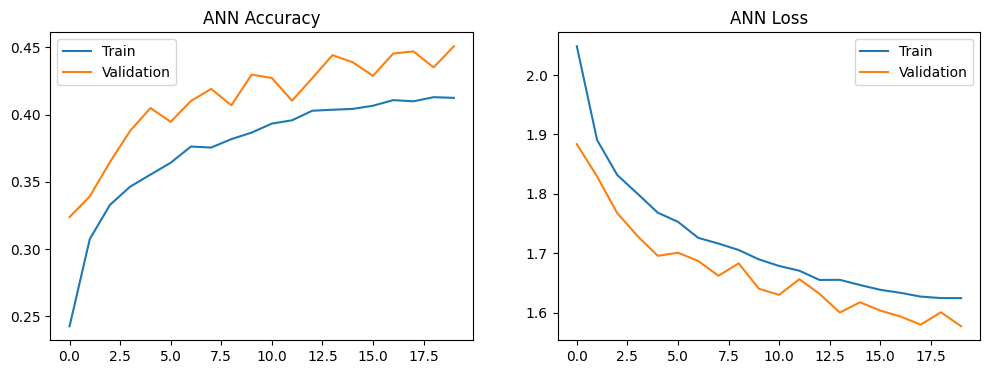

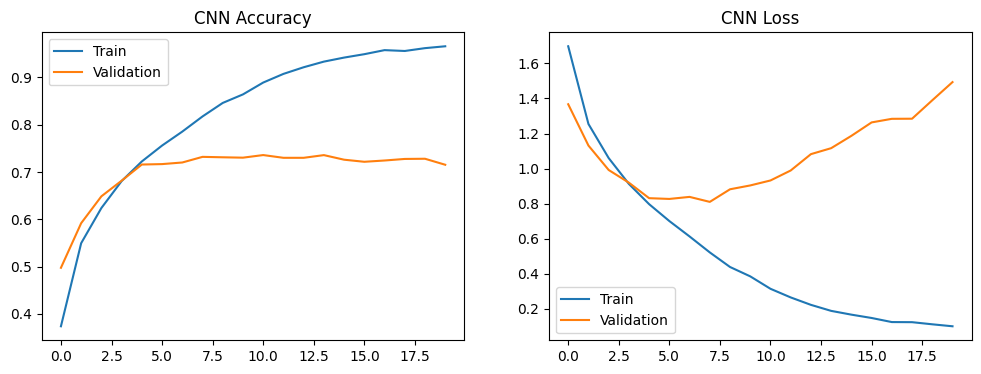

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{title} Loss')
    plt.legend()

    plt.show()

plot_history(history_ann, "ANN")
plot_history(history_cnn, "CNN")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

ANN Classification Report:

              precision    recall  f1-score   support

           0       0.56      0.45      0.50      1000
           1       0.59      0.56      0.58      1000
           2       0.33      0.18      0.23      1000
           3       0.32      0.39      0.35      1000
           4       0.34      0.58      0.43      1000
           5       0.47      0.26      0.33      1000
           6       0.46      0.51      0.48      1000
           7       0.46      0.54      0.50      1000
           8       0.62      0.60      0.61      1000
           9       0.53      0.52      0.52      1000

    accuracy                           0.46     10000
   macro avg       0.47      0.46      0.45     10000
weighted avg       0.47      0.46      0.45     10000



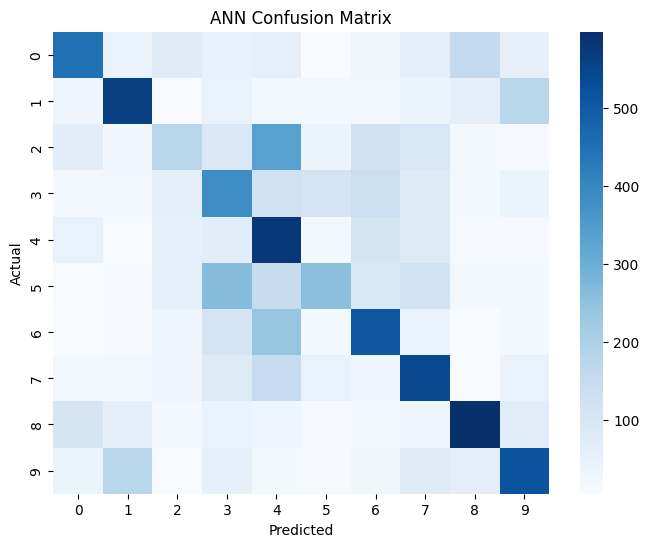

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step

CNN Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.76      0.74      1000
           1       0.80      0.87      0.83      1000
           2       0.57      0.62      0.59      1000
           3       0.48      0.57      0.52      1000
           4       0.72      0.57      0.64      1000
           5       0.58      0.63      0.60      1000
           6       0.82      0.73      0.77      1000
           7       0.84      0.70      0.76      1000
           8       0.80      0.83      0.82      1000
           9       0.83      0.74      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.71     10000
weighted avg       0.71      0.70      0.71     10000



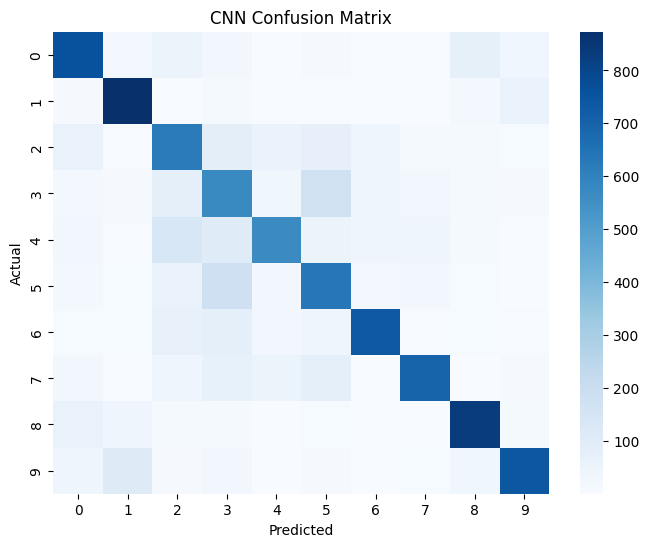

In [ ]:
def evaluate_model(model, name):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = y_test.flatten()

    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return y_pred

ann_pred = evaluate_model(ann, "ANN")
cnn_pred = evaluate_model(cnn, "CNN")

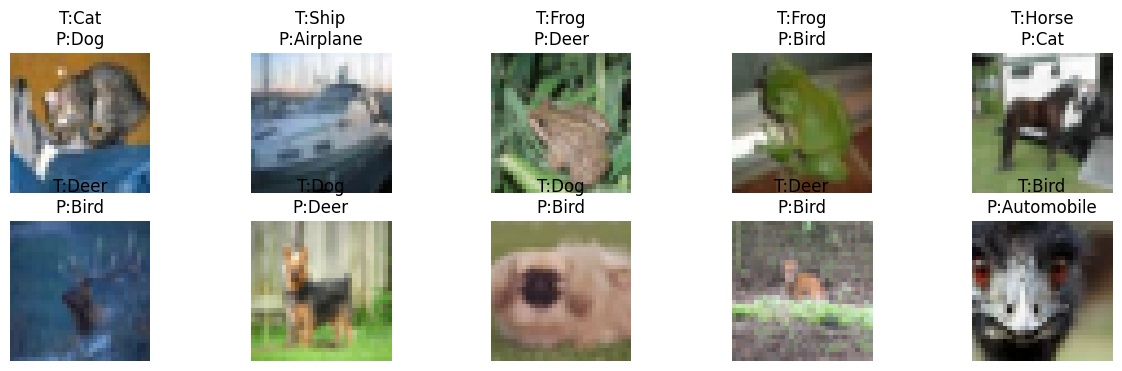

In [ ]:
misclassified = np.where(cnn_pred != y_test.flatten())[0][:10]

plt.figure(figsize=(15,4))
for i, idx in enumerate(misclassified):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx])
    plt.title(f"T:{class_names[y_test[idx][0]]}\nP:{class_names[cnn_pred[idx]]}")
    plt.axis('off')
plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Parameters": [ann.count_params(), cnn.count_params()],
    "Test Accuracy": [ann_acc, cnn_acc],
    "Training Time (sec)": [ann_time, cnn_time]
})

comparison

,Model,Parameters,Test Accuracy,Training Time (sec)
0,ANN,1738890,0.4579,374.836798
1,CNN,980810,0.7036,6035.359421


Summary

In this assignment, CIFAR-10 image classification is done using ANN and CNN models. The images was normalized and labels are converted into one hot encoding before the training process. The ANN model use fully connected layers but it does not understand spatial features very well, so the accuracy is not very high. On the other hand, the CNN model performs better becuase it can learn image pattrens like edges and shapes. Overall, CNN gives better performance for image classification when compare to ANN model.